# Customer Churn Prediction & CLV Modelling
Organized notebook with improved structure and best practices.

## 1. Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay,
    accuracy_score, precision_score,
    recall_score, f1_score,
    precision_recall_curve
)

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix
)

sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load Data

In [21]:
df = pd.read_parquet("../data/processed/features_segmented.parquet")
df.head()

,CustomerID,Recency,Frequency,Monetary,Log_Monetary,Log_Frequency,AOV,SpendStd,PreferredDayOfWeek,WeekendRatio,...,StdGap,ReturnRate,CohortMonth,ActiveMonths,DaysSinceFirstPurchase,Recency_scaled,Log_Frequency_scaled,Log_Monetary_scaled,Segment,SegmentLabel
0,12347,2,7,4060.40,8.309283,2.079442,580.057143,351.455168,1,0.000000,...,18.478817,0.000000,2010-12,7,365,-0.905907,1.095687,1.456634,1,Loyal Customers
1,12348,75,4,1186.68,7.079757,1.609438,296.670000,225.294269,3,0.095238,...,70.149840,0.000000,2010-12,4,282,-0.175777,0.401171,0.464159,1,Loyal Customers
2,12349,19,1,1353.80,7.211409,0.693147,1353.800000,0.000000,0,0.000000,...,0.000000,0.000000,2011-11,1,0,-0.735876,-0.952816,0.570429,0,Champions
3,12350,310,1,294.40,5.688330,0.693147,294.400000,0.000000,2,0.000000,...,0.000000,0.000000,2011-02,1,0,2.174640,-0.952816,-0.659003,2,Lost / Inactive
4,12352,36,7,1385.74,7.234711,2.079442,197.962857,81.916277,1,0.000000,...,68.419296,0.909091,2011-02,4,260,-0.565846,1.095687,0.589238,1,Loyal Customers


## 3. Create Churn Label

In [22]:
CHURN_THRESHOLD = 90
df["Churned"] = (df["Recency"] > CHURN_THRESHOLD).astype(int)

if "Segment" in df.columns and not np.issubdtype(df["Segment"].dtype, np.number):
    df["Segment"] = df["Segment"].astype("category").cat.codes

## 4. Feature Selection

In [23]:
FEATURE_COLS=[
"Frequency","Monetary","AOV","SpendStd",
"UniqueSKUs","RepeatSKURatio","TotalItems",
"AvgGap","StdGap","WeekendRatio",
"PreferredDayOfWeek","ActiveMonths",
"DaysSinceFirstPurchase","ReturnRate","Segment"
]

X=df[FEATURE_COLS].fillna(0)
y=df["Churned"]

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42,stratify=y)

## 5. Cross Validation

In [24]:
model=xgb.XGBClassifier(
n_estimators=300,
max_depth=5,
learning_rate=0.05,
subsample=0.8,
colsample_bytree=0.8,
scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
eval_metric="auc",
random_state=42)

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,X_train,y_train,cv=cv,scoring="roc_auc")
print("Mean ROC-AUC:",scores.mean())

Mean ROC-AUC: 0.9026302825133747


## 6. Train Model

In [25]:
model.fit(X_train,y_train)
y_proba=model.predict_proba(X_test)[:,1]

precision,recall,thresholds=precision_recall_curve(y_test,y_proba)
f1=2*precision[:-1]*recall[:-1]/(precision[:-1]+recall[:-1]+1e-9)
threshold=thresholds[np.argmax(f1)]

print("Best Threshold:",threshold)

y_pred=(y_proba>threshold).astype(int)

Best Threshold: 0.6439786


## 7. Evaluation

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       572
           1       0.99      0.64      0.78       286

    accuracy                           0.88       858
   macro avg       0.92      0.82      0.85       858
weighted avg       0.90      0.88      0.87       858

ROC-AUC: 0.8983140984889237
Accuracy: 0.87995337995338
Precision: 0.9945945945945946
Recall: 0.6433566433566433
F1: 0.7813163481953291


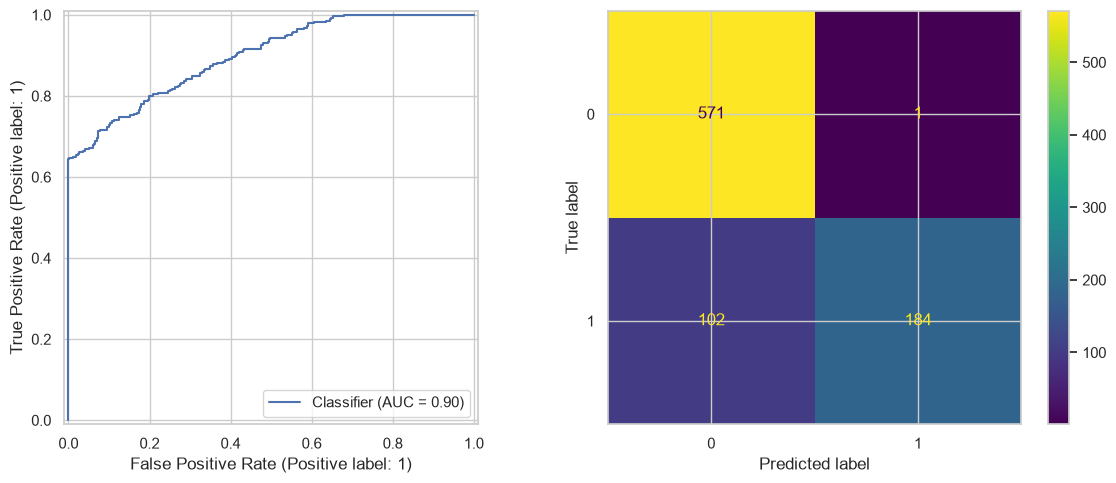

In [26]:
print(classification_report(y_test,y_pred))
print("ROC-AUC:",roc_auc_score(y_test,y_proba))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1:",f1_score(y_test,y_pred))

fig,ax=plt.subplots(1,2,figsize=(12,5))
RocCurveDisplay.from_predictions(y_test,y_proba,ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,ax=ax[1])
plt.tight_layout()
plt.show()

## 8. Explainability

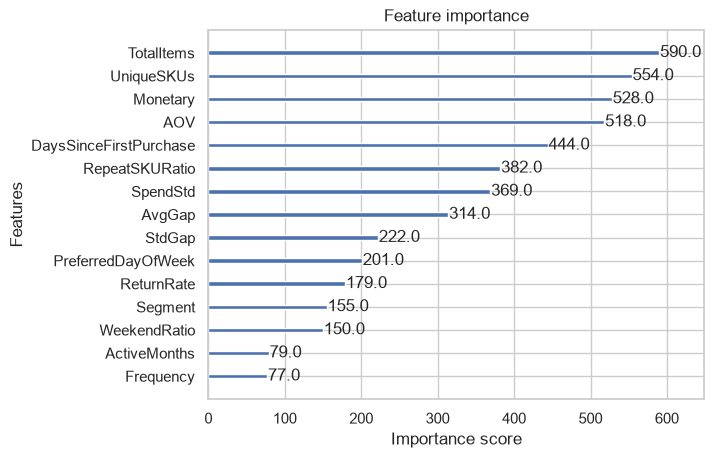

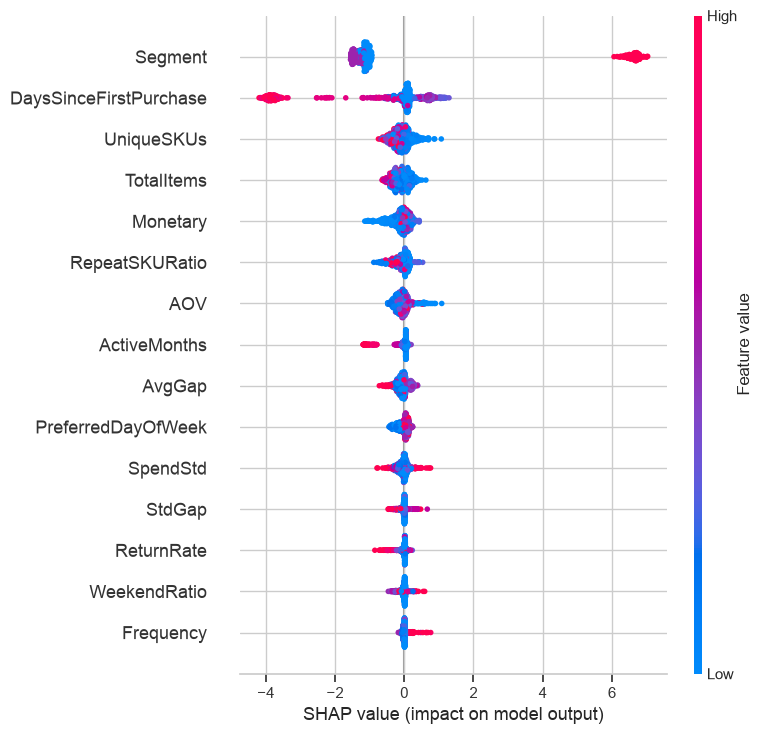

In [27]:
xgb.plot_importance(model,max_num_features=15)
plt.show()

explainer=shap.TreeExplainer(model)
shap_values=explainer(X_test)
shap.summary_plot(shap_values,X_test)

## 9. Save Churn Model

In [28]:
df["ChurnProb"]=model.predict_proba(X)[:,1]

Path("../models/artifacts").mkdir(parents=True,exist_ok=True)
joblib.dump(model,"../models/artifacts/churn_xgb.joblib")

['../models/artifacts/churn_xgb.joblib']

## 10. Prepare CLV Data

In [29]:
raw=pd.read_parquet("../data/interim/cleaned.parquet")
raw["InvoiceDate"]=pd.to_datetime(raw["InvoiceDate"])

summary=summary_data_from_transaction_data(
raw,
customer_id_col="CustomerID",
datetime_col="InvoiceDate",
monetary_value_col="Revenue",
observation_period_end=raw["InvoiceDate"].max()
)

summary=summary[summary["frequency"]>0]
print(summary[["frequency","monetary_value"]].corr())

                frequency  monetary_value
frequency        1.000000        0.128122
monetary_value   0.128122        1.000000


## 11. BG/NBD & Gamma-Gamma

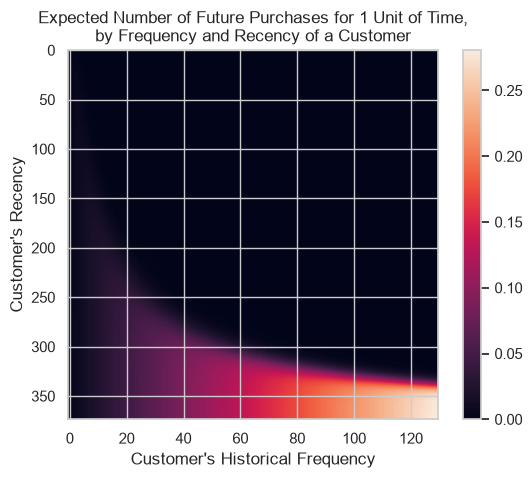

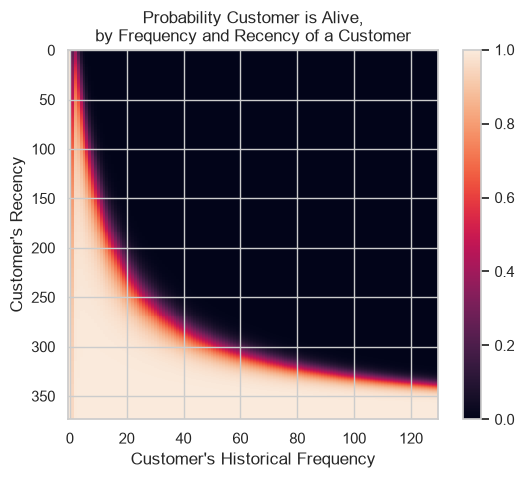

In [31]:
bgf=BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary["frequency"],summary["recency"],summary["T"])

ggf=GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary["frequency"],summary["monetary_value"])

plot_frequency_recency_matrix(bgf)
plt.show()

plot_probability_alive_matrix(bgf)
plt.show()

summary["ProbabilityAlive"]=bgf.conditional_probability_alive(
summary["frequency"],summary["recency"],summary["T"])

summary["ExpectedPurchases12M"]=bgf.conditional_expected_number_of_purchases_up_to_time(
365,
summary["frequency"],summary["recency"],summary["T"])

summary["PredictedCLV_12M"]=ggf.customer_lifetime_value(
bgf,
summary["frequency"],
summary["recency"],
summary["T"],
summary["monetary_value"],
time=12,
discount_rate=0.01
)

## 12. Merge CLV

In [32]:
df=df.merge(
summary[["PredictedCLV_12M","ProbabilityAlive","ExpectedPurchases12M"]].reset_index(),
on="CustomerID",
how="left"
)

df["CLVTier"]="No CLV"
mask=df["PredictedCLV_12M"]>0

labels=["Bronze","Silver","Gold","Platinum"]

df.loc[mask,"CLVTier"]=pd.qcut(
df.loc[mask,"PredictedCLV_12M"],
q=4,
labels=labels,
duplicates="drop"
)

## 13. Business Strategy

In [33]:
median=df["PredictedCLV_12M"].median()

conditions=[
(df["ChurnProb"]>0.6)&(df["PredictedCLV_12M"]>median),
(df["ChurnProb"]>0.6),
(df["PredictedCLV_12M"]>median)
]

choices=[
"Retain Immediately",
"Retention Campaign",
"Upsell Opportunity"
]

df["CustomerStrategy"]=np.select(
conditions,
choices,
default="Maintain"
)

print(df["CustomerStrategy"].value_counts())

CustomerStrategy
Maintain              1793
Upsell Opportunity    1313
Retention Campaign    1125
Retain Immediately      59
Name: count, dtype: int64


## 14. Visualisations

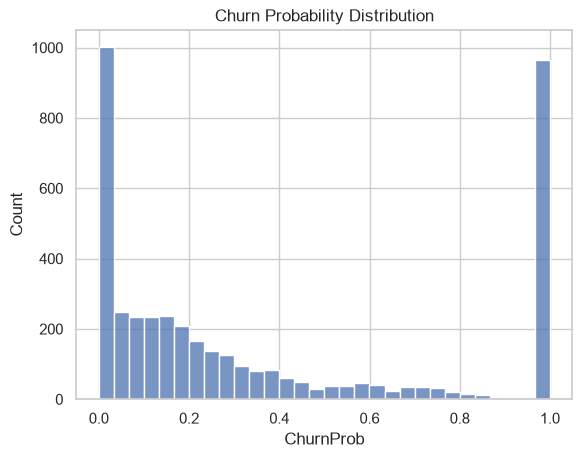

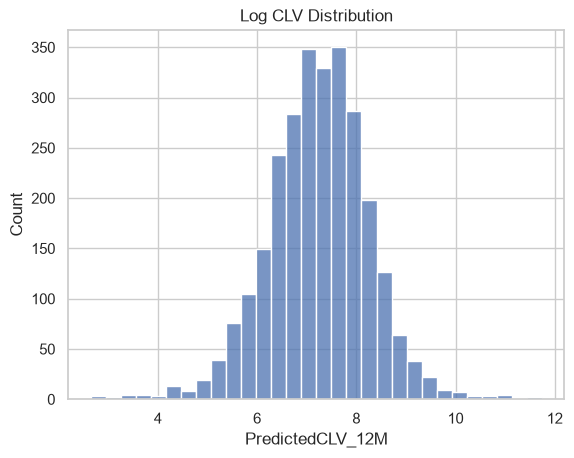

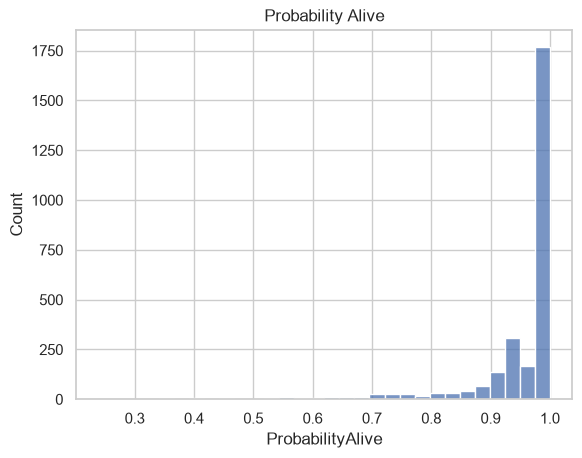

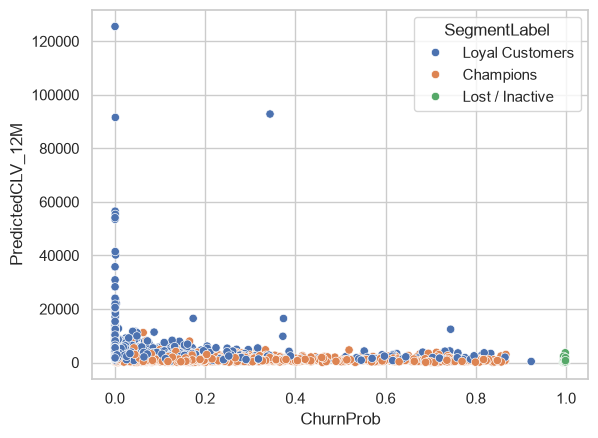

,CustomerID,PredictedCLV_12M,ChurnProb
CustomerStrategy,,,
Maintain,1793,826.947184,0.196978
Retain Immediately,59,2573.801750,0.744780
Retention Campaign,1125,540.898995,0.955909
Upsell Opportunity,1313,4091.014170,0.082937


In [34]:
sns.histplot(df["ChurnProb"],bins=30)
plt.title("Churn Probability Distribution")
plt.show()

sns.histplot(np.log1p(df["PredictedCLV_12M"]),bins=30)
plt.title("Log CLV Distribution")
plt.show()

sns.histplot(df["ProbabilityAlive"],bins=30)
plt.title("Probability Alive")
plt.show()

sns.scatterplot(data=df,x="ChurnProb",y="PredictedCLV_12M",hue="SegmentLabel")
plt.show()

summary_table=df.groupby("CustomerStrategy").agg({
"CustomerID":"count",
"PredictedCLV_12M":"mean",
"ChurnProb":"mean"
})

display(summary_table)

## 15. Save Outputs

In [35]:
df.to_parquet("../data/processed/features_final.parquet",index=False)
print("Pipeline completed successfully.")

Pipeline completed successfully.
